In [3]:
from pathlib import Path

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# need this to be relative to jupyter, not this file
DATA_DIR = Path("../data")

IMAGE_DIR = DATA_DIR / "images"
MASK_DIR = DATA_DIR / "masks"

print(IMAGE_DIR, MASK_DIR)

../data/images ../data/masks


In [4]:
for split in ["train", "val"]:
    for data_type in ["images", "masks"]:
        path = DATA_DIR / data_type / split
        files = sorted(path.glob("*.png"))
        print(f"{data_type:>6} | {split:>5} | {len(files):>5}")

images | train |  6455
 masks | train |  6455
images |   val |  1615
 masks |   val |  1615


In [5]:
for split in ["train", "val"]:
    image_names = {
        p.name for p in (IMAGE_DIR / split).glob("*.png")
    }

    mask_names = {
        p.name for p in (MASK_DIR / split).glob("*.png")
    }

    print(f"\nImages in {split}:")
    print("Images without masks:", len(image_names - mask_names))
    print("Masks without images:", len(mask_names - image_names))

    if len(image_names - mask_names)==len(mask_names - image_names)==0:
        print("Pass!")


Images in train:
Images without masks: 0
Masks without images: 0
Pass!

Images in val:
Images without masks: 0
Masks without images: 0
Pass!


In [6]:
def check_dimensions(directory):
    bad = []

    for path in directory.glob("*.png"):
        with Image.open(path) as img:
            if img.size != (256, 256):
                bad.append((path.name, img.size))

    return bad


for split in ["train", "val"]:
    for data_type in ["images", "masks"]:
        bad = check_dimensions(DATA_DIR / data_type / split)

        print(
            f"{data_type}/{split}: "
            f"{len(bad)} images with incorrect dimensions"
        )

        if bad:
            print(bad[:10])

images/train: 0 images with incorrect dimensions
masks/train: 0 images with incorrect dimensions
images/val: 0 images with incorrect dimensions
masks/val: 0 images with incorrect dimensions


In [7]:
mask_paths = sorted((MASK_DIR / "train").glob("*.png"))

for path in mask_paths[::300]:
    mask = np.array(Image.open(path))
    print(path.name, np.unique(mask))

palsar_0.png [  0 255]
palsar_1268.png [  0   1   2   3   4   6   7   8   9  11  12  13  14  15  17  18  19  21
  23  24  25  26  28  30  32  33  34  37  38  39  41  42  43  46  47  48
  51  53  54  55  56  57  58  59  60  61  62  64  66  67  68  69  70  72
  74  75  76  78  79  81  83  84  85  86  87  88  89  91  95  96  97  98
 101 102 103 105 107 109 110 111 112 115 117 118 119 121 123 124 132 133
 134 135 137 138 139 140 141 143 144 145 146 149 150 152 153 157 159 160
 161 163 164 166 167 168 170 171 172 173 174 177 179 180 181 183 185 188
 189 193 194 195 196 197 198 199 200 201 202 204 206 208 209 210 211 212
 213 214 215 216 217 218 220 221 222 223 224 225 227 229 230 232 234 236
 237 238 240 241 242 243 244 245 246 247 248 249 250 252 253 254 255]
palsar_1538.png [  0   1   2   3   5   8   9  10  12  13  15  17  19  20  21  23  25  28
  30  32  34  37  42  43  45  46  51  54  55  56  57  58  60  63  65  68
  69  70  72  75  78  84  85  89  94  96  98 103 106 108 110 114 117 118

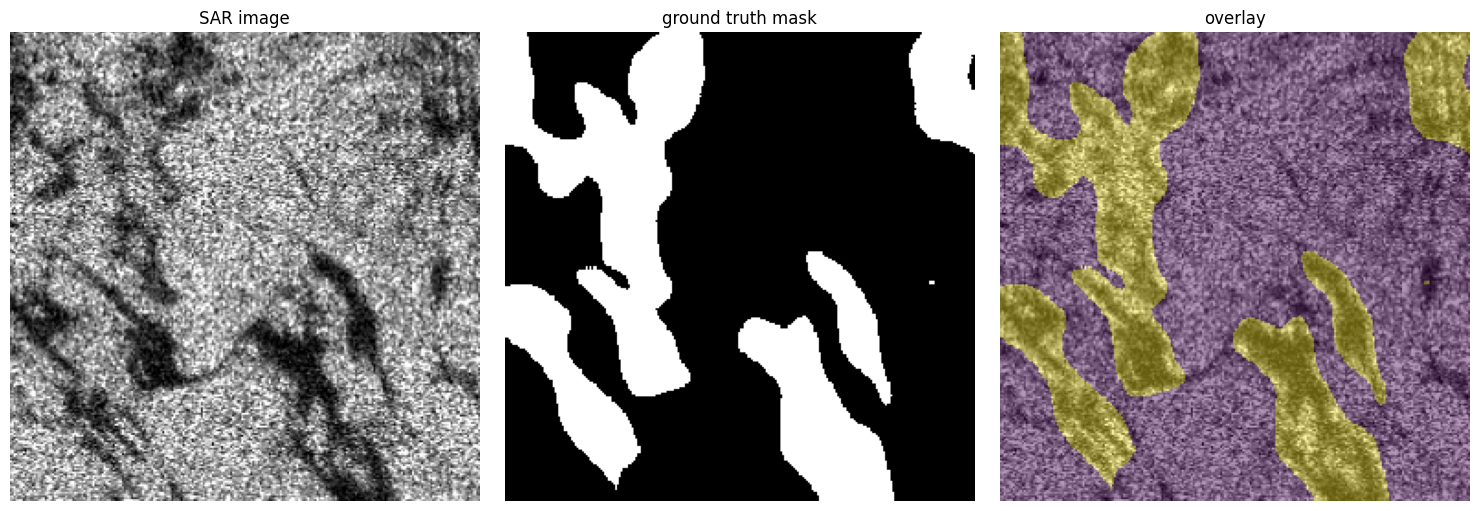

In [8]:
def show_sample(name):
    image_path = IMAGE_DIR / "train" / name
    mask_path = MASK_DIR / "train" / name

    image = np.array(Image.open(image_path))
    mask = np.array(Image.open(mask_path))

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(image, cmap="gray")
    axes[0].set_title("SAR image")
    axes[0].axis("off")

    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title("ground truth mask")
    axes[1].axis("off")

    axes[2].imshow(image, cmap="gray")
    axes[2].imshow(mask, alpha=0.4)
    axes[2].set_title("overlay")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

show_sample("sentinel_2129.png")

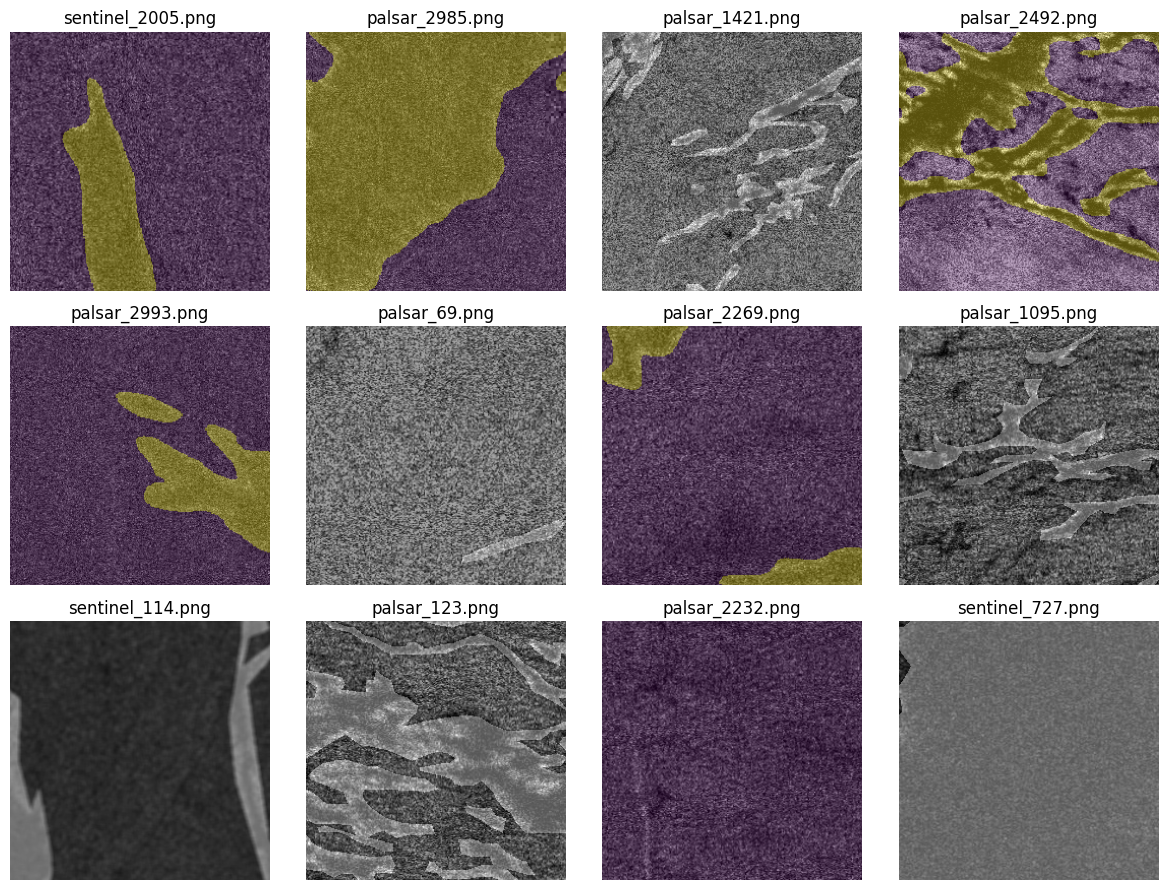

In [9]:
import random

sample_paths = random.sample(
    list((IMAGE_DIR / "train").glob("*.png")),
    12
)

fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for ax, image_path in zip(axes.flat, sample_paths):
    image = np.array(Image.open(image_path))
    mask = np.array(
        Image.open(MASK_DIR / "train" / image_path.name)
    )

    ax.imshow(image, cmap="gray")
    ax.imshow(mask, alpha=0.35)
    ax.set_title(image_path.name)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [10]:
from collections import Counter

for split in ["train", "val"]:
    names = [
        p.stem
        for p in (IMAGE_DIR / split).glob("*.png")
    ]

    sensor_counts = Counter(
        name.split("_")[0].lower()
        for name in names
    )

    print(split, sensor_counts)

train Counter({'sentinel': 3354, 'palsar': 3101})
val Counter({'sentinel': 839, 'palsar': 776})


In [11]:
sample_path = sorted(
    (IMAGE_DIR / "train").glob("*.png")
)[0]

image = np.array(Image.open(sample_path))

print("dtype:", image.dtype)
print("shape:", image.shape)
print("min:", image.min())
print("max:", image.max())
print("mean:", image.mean())
print("std:", image.std())

dtype: uint8
shape: (256, 256, 3)
min: 0
max: 255
mean: 155.21926879882812
std: 47.23592511931416


In [12]:
mask_path = MASK_DIR / "train" / sample_path.name

mask = np.array(Image.open(mask_path))

print("dtype:", mask.dtype)
print("shape:", mask.shape)
print("unique values:", np.unique(mask))

dtype: uint8
shape: (256, 256, 3)
unique values: [  0 255]


Some masks seem to be antialiased... best to fix them up.

In [13]:
for split in ["train", "val"]:
    mask_dir = Path("data/masks") / split

    total = 0
    binary = 0
    antialiased = 0

    for path in mask_dir.glob("*.png"):
        mask = np.array(Image.open(path))

        total += 1

        unique = np.unique(mask)

        if np.all(np.isin(unique, [0, 255])):
            binary += 1
        else:
            antialiased += 1

    print(f"{split}:")
    print(f"  total:       {total}")
    print(f"  binary:      {binary}")
    print(f"  antialiased: {antialiased}")

train:
  total:       0
  binary:      0
  antialiased: 0
val:
  total:       0
  binary:      0
  antialiased: 0


In [15]:
for path in [
    Path("../data/masks/train/sentinel_86.png")
]:
    mask = np.array(Image.open(path))

    intermediate = (mask > 0) & (mask < 255)

    print(path.name)
    print("total pixels:", mask.size)
    print("intermediate pixels:", intermediate.sum())
    print(
        "percentage:",
        intermediate.mean() * 100
    )

sentinel_86.png
total pixels: 196608
intermediate pixels: 18549
percentage: 9.43450927734375


How many are all zero?

In [16]:
for split in ["train", "val"]:
    mask_dir = Path("../data/masks") / split

    empty = 0
    non_empty = 0

    for path in mask_dir.glob("*.png"):
        mask = np.array(Image.open(path))

        # threshold anti-aliased masks
        binary = mask >= 128

        if binary.any():
            non_empty += 1
        else:
            empty += 1

    print(split)
    print("  empty:", empty)
    print("  spill:", non_empty)

train
  empty: 255
  spill: 6200
val
  empty: 76
  spill: 1539


In [17]:
spill_percentages = []

mask_dir = Path("../data/masks/train")

for path in mask_dir.glob("*.png"):
    mask = np.array(Image.open(path))
    binary = mask >= 128

    percentage = binary.mean() * 100
    spill_percentages.append(percentage)

spill_percentages = np.array(spill_percentages)

print("min:", spill_percentages.min())
print("max:", spill_percentages.max())
print("mean:", spill_percentages.mean())
print("median:", np.median(spill_percentages))

min: 0.0
max: 100.0
mean: 24.944682575583364
median: 17.93670654296875


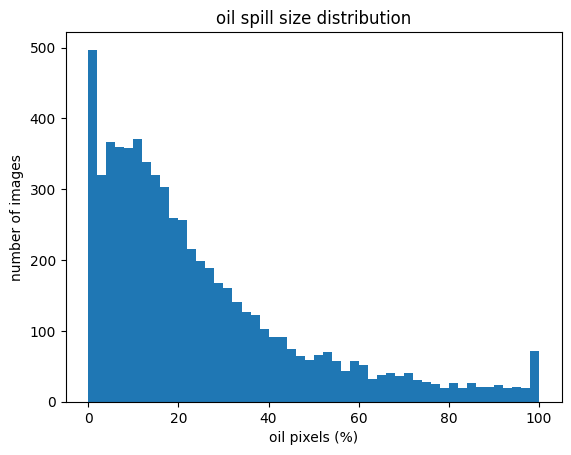

In [18]:
plt.hist(spill_percentages, bins=50)
plt.xlabel("oil pixels (%)")
plt.ylabel("number of images")
plt.title("oil spill size distribution")
plt.show()

In [19]:
for sensor in ["sentinel", "palsar"]:
    values = []

    for path in Path("../data/images/train").glob(f"{sensor}_*.png"):
        image = np.array(Image.open(path)).astype(np.float32)
        values.append(image.flatten())

    values = np.concatenate(values)

    print(f"\n{sensor.upper()}")
    print("dtype:", image.dtype)
    print("min:", values.min())
    print("max:", values.max())
    print("mean:", values.mean())
    print("std:", values.std())
    print("p1:", np.percentile(values, 1))
    print("p99:", np.percentile(values, 99))


SENTINEL
dtype: float32
min: 0.0
max: 255.0
mean: 97.94222
std: 51.470158
p1: 8.0
p99: 243.0

PALSAR
dtype: float32
min: 0.0
max: 255.0
mean: 119.68424
std: 55.17266
p1: 5.0
p99: 252.0
